In [70]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [71]:
import os

train_dir = "../datasets/train"

normal_count = len(os.listdir(train_dir + "/NORMAL"))
pneumonia_count = len(os.listdir(train_dir + "/PNEUMONIA"))

print("Normal Images:", normal_count)
print("Pneumonia Images:", pneumonia_count)

Normal Images: 1341
Pneumonia Images: 3875


In [72]:
from PIL import Image
import os

normal_folder = "../datasets/train/NORMAL"

image_name = os.listdir(normal_folder)[0]
image_path = os.path.join(normal_folder, image_name)

img = Image.open(image_path)

print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (2090, 1858)
Image Mode: L


In [73]:
print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (2090, 1858)
Image Mode: L


In [74]:
from PIL import Image
import os

normal_folder = "../datasets/train/NORMAL"

image_name = os.listdir(normal_folder)[0]
image_path = os.path.join(normal_folder, image_name)

img = Image.open(image_path)

print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (2090, 1858)
Image Mode: L


Original Size: (2090, 1858)
Resized Size: (64, 64)


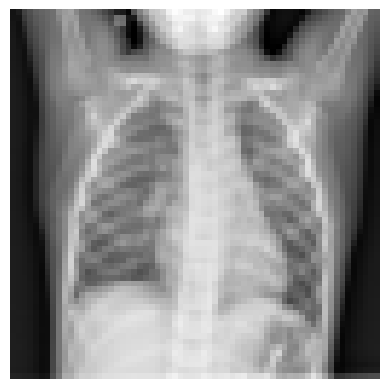

In [75]:
img_resized = img.resize((64, 64))

print("Original Size:", img.size)
print("Resized Size:", img_resized.size)

plt.imshow(img_resized, cmap="gray")
plt.axis("off")
plt.show()

Original Size: (64, 64)
Resized Size: (64, 64)


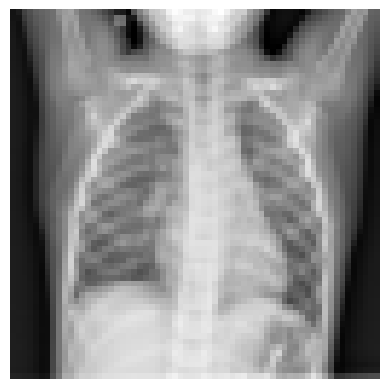

In [76]:
from PIL import Image
import matplotlib.pyplot as plt
import os

normal_folder = "../datasets/train/NORMAL"

image_name = os.listdir(normal_folder)[0]
image_path = os.path.join(normal_folder, image_name)

img = Image.open(image_path)

# Force grayscale
img = img.convert("L")

img = img.resize((64, 64))

print("Original Size:", img.size)
print("Resized Size:", img_resized.size)

plt.imshow(img_resized, cmap="gray")
plt.axis("off")
plt.show()


In [77]:
import numpy as np

img_array = np.array(img_resized)

print(img_array.shape)


(64, 64)


In [78]:
flat_img = img_array.flatten()

print(flat_img.shape)

(4096,)


In [79]:
X = []
y = []

In [80]:
import os
import numpy as np
from PIL import Image

# NORMAL images
normal_folder = "../datasets/train/NORMAL"

for filename in os.listdir(normal_folder):
    image_path = os.path.join(normal_folder, filename)

    img = Image.open(image_path)
    img = img.resize((64, 64))

    img_array = np.array(img)

    flat_img = img_array.flatten()

    X.append(flat_img)
    y.append(0)

In [81]:
print(len(X))
print(len(y))

1341
1341


In [82]:
pneumonia_folder = "../datasets/train/PNEUMONIA"

for filename in os.listdir(pneumonia_folder):
    image_path = os.path.join(pneumonia_folder, filename)

    try:
        img = Image.open(image_path)
        img = img.resize((64, 64))

        img_array = np.array(img)

        flat_img = img_array.flatten()

        X.append(flat_img)
        y.append(1)

    except:
        pass
    

In [83]:
print("Total Samples:", len(X))
print("Total Labels:", len(y))

Total Samples: 5216
Total Labels: 5216


In [84]:
import numpy as np

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5216,) + inhomogeneous part.

In [ ]:
print(X[0].shape)
print(X[100].shape)
print(X[1000].shape)

(4096,)
(4096,)
(4096,)


In [ ]:
for i, img in enumerate(X):
    if len(img) != 4096:
        print("Problem at index:", i)
        print("Shape:", img.shape)
        break

Problem at index: 1359
Shape: (12288,)


In [ ]:
lengths = set(len(img) for img in X)
print(lengths)

{4096, 12288}


In [ ]:
import numpy as np
import os
from PIL import Image

X = []
y = []

In [ ]:
normal_folder = "../datasets/train/NORMAL"

for filename in os.listdir(normal_folder):

    image_path = os.path.join(normal_folder, filename)

    try:
        img = Image.open(image_path)

        img = img.convert("L")

        img = img.resize((64, 64))

        img_array = np.array(img)

        flat_img = img_array.flatten()

        X.append(flat_img)
        y.append(0)

    except:
        pass

In [ ]:
pneumonia_folder = "../datasets/train/PNEUMONIA"

for filename in os.listdir(pneumonia_folder):

    image_path = os.path.join(pneumonia_folder, filename)

    try:
        img = Image.open(image_path)

        img = img.convert("L")

        img = img.resize((64, 64))

        img_array = np.array(img)

        flat_img = img_array.flatten()

        X.append(flat_img)
        y.append(1)

    except:
        pass

In [ ]:
lengths = set(len(img) for img in X)

print(lengths)

{4096}


In [ ]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(5216, 4096)
(5216,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4172, 4096)
X_test: (1044, 4096)
y_train: (4172,)
y_test: (1044,)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 1 1 1 1 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9568965517241379


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[262  25]
 [ 20 737]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       287
           1       0.97      0.97      0.97       757

    accuracy                           0.96      1044
   macro avg       0.95      0.94      0.95      1044
weighted avg       0.96      0.96      0.96      1044



In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[262  25]
 [ 20 737]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       287
           1       0.97      0.97      0.97       757

    accuracy                           0.96      1044
   macro avg       0.95      0.94      0.95      1044
weighted avg       0.96      0.96      0.96      1044



In [ ]:
from PIL import Image
import numpy as np

def predict_xray(image_path):

    img = Image.open(image_path)

    img = img.convert("L")

    img = img.resize((64,64))

    img_array = np.array(img)

    flat_img = img_array.flatten()

    flat_img = flat_img.reshape(1, -1)

    prediction = model.predict(flat_img)

    if prediction[0] == 0:
        print("Normal")
    else:
        print("Pneumonia")

In [ ]:
predict_xray("path_to_xray_image.jpeg")

FileNotFoundError: [Errno 2] No such file or directory: 'path_to_xray_image.jpeg'

In [ ]:
import os

test_normal = "../datasets/test/NORMAL"

print(os.listdir(test_normal)[:5])

['IM-0001-0001.jpeg', 'IM-0003-0001.jpeg', 'IM-0005-0001.jpeg', 'IM-0006-0001.jpeg', 'IM-0007-0001.jpeg']


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_xray(image_path):

    img = Image.open(image_path)

    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    img = img.convert("L")
    img = img.resize((64,64))

    img_array = np.array(img)
    flat_img = img_array.flatten().reshape(1, -1)

    prediction = model.predict(flat_img)

    print("Raw Prediction:", prediction)

    prob = model.predict_proba(flat_img)
    print("Probabilities:", prob)

    if prediction[0] == 0:
        print("Prediction: NORMAL")
    else:
        print("Prediction: PNEUMONIA")

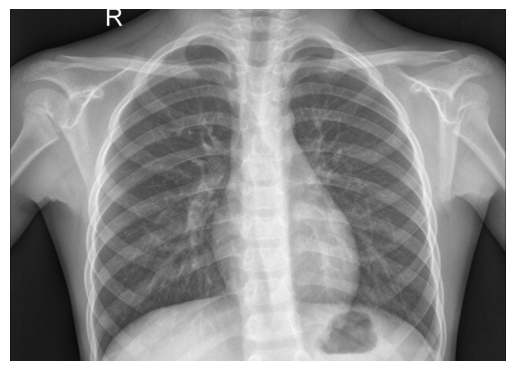

Raw Prediction: [1]
Probabilities: [[8.8817842e-16 1.0000000e+00]]
Prediction: PNEUMONIA


In [ ]:
predict_xray("../datasets/test/NORMAL/IM-0001-0001.jpeg")

In [ ]:
import os

print(os.listdir("../datasets/test/NORMAL")[:5])

['IM-0001-0001.jpeg', 'IM-0003-0001.jpeg', 'IM-0005-0001.jpeg', 'IM-0006-0001.jpeg', 'IM-0007-0001.jpeg']


In [ ]:
predict_xray("../datasets/test/PNEUMONIA/person1_bacteria_1.jpeg")

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/test/PNEUMONIA/person1_bacteria_1.jpeg'

In [ ]:
print(os.listdir("../datasets/test/NORMAL")[:5])

['IM-0001-0001.jpeg', 'IM-0003-0001.jpeg', 'IM-0005-0001.jpeg', 'IM-0006-0001.jpeg', 'IM-0007-0001.jpeg']


In [ ]:
predict_xray("../datasets/test/NORMAL/IM-0001-0001.jpeg")

Prediction: PNEUMONIA


In [ ]:
print(os.listdir("../datasets/test/PNEUMONIA")[:5])

['person100_bacteria_475.jpeg', 'person100_bacteria_477.jpeg', 'person100_bacteria_478.jpeg', 'person100_bacteria_479.jpeg', 'person100_bacteria_480.jpeg']


In [ ]:
predict_xray("../datasets/test/PNEUMONIA/person1_bacteria_1.jpeg")

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/test/PNEUMONIA/person1_bacteria_1.jpeg'

In [ ]:
import os

print(os.listdir("../datasets/test/PNEUMONIA")[:10])

['person100_bacteria_475.jpeg', 'person100_bacteria_477.jpeg', 'person100_bacteria_478.jpeg', 'person100_bacteria_479.jpeg', 'person100_bacteria_480.jpeg', 'person100_bacteria_481.jpeg', 'person100_bacteria_482.jpeg', 'person101_bacteria_483.jpeg', 'person101_bacteria_484.jpeg', 'person101_bacteria_485.jpeg']


In [ ]:
predict_xray("../datasets/test/PNEUMONIA/person100_bacteria_475.jpeg")

Prediction: PNEUMONIA


In [ ]:
print(os.listdir("../datasets/test/PNEUMONIA")[:10])

['person100_bacteria_475.jpeg', 'person100_bacteria_477.jpeg', 'person100_bacteria_478.jpeg', 'person100_bacteria_479.jpeg', 'person100_bacteria_480.jpeg', 'person100_bacteria_481.jpeg', 'person100_bacteria_482.jpeg', 'person101_bacteria_483.jpeg', 'person101_bacteria_484.jpeg', 'person101_bacteria_485.jpeg']


In [ ]:
print(os.path.exists("../datasets/test/PNEUMONIA"))

True


In [ ]:
predict_xray("../datasets/test/PNEUMONIA/person100_bacteria_475.jpeg")

Prediction: PNEUMONIA


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_xray(image_path):

    img = Image.open(image_path)

    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    img = img.convert("L")
    img = img.resize((64,64))

    img_array = np.array(img)
    flat_img = img_array.flatten().reshape(1, -1)

    prediction = model.predict(flat_img)

    if prediction[0] == 0:
        print("Prediction: NORMAL")
    else:
        print("Prediction: PNEUMONIA")

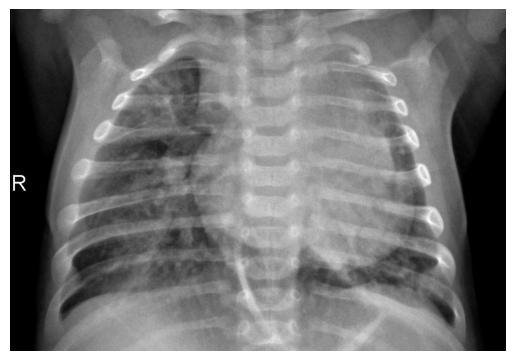

Prediction: PNEUMONIA


In [ ]:
predict_xray("../datasets/test/PNEUMONIA/person100_bacteria_475.jpeg")

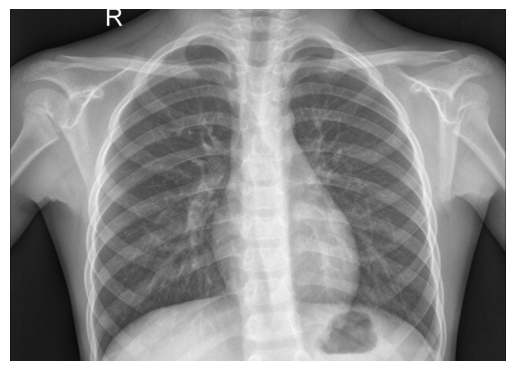

Prediction: PNEUMONIA


In [ ]:
predict_xray("../datasets/test/NORMAL/IM-0001-0001.jpeg")

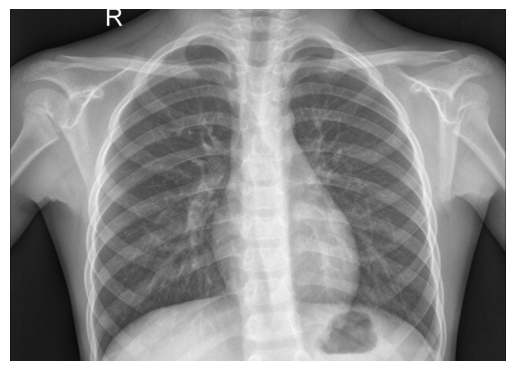

Prediction: PNEUMONIA


In [ ]:
predict_xray("../datasets/test/NORMAL/IM-0001-0001.jpeg")

In [ ]:
print(y_test[:20])

[1 0 1 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1]


In [ ]:
print(y_pred[:20])

[1 0 1 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1]


In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[262  25]
 [ 20 737]]


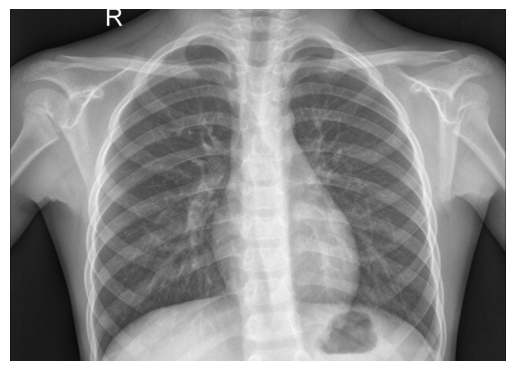

Raw Prediction: [1]
Probabilities: [[8.8817842e-16 1.0000000e+00]]
Prediction: PNEUMONIA


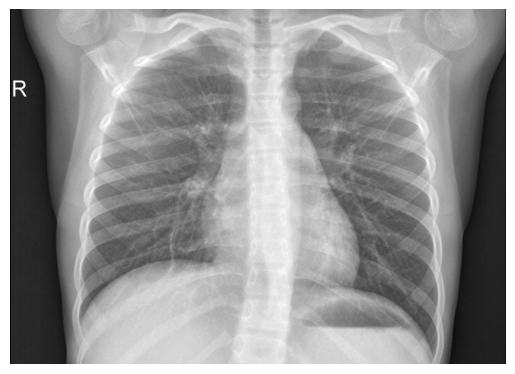

Raw Prediction: [1]
Probabilities: [[0. 1.]]
Prediction: PNEUMONIA


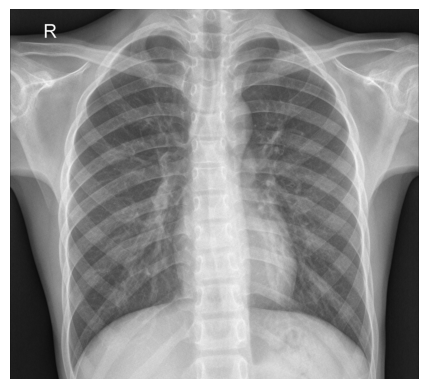

Raw Prediction: [1]
Probabilities: [[0. 1.]]
Prediction: PNEUMONIA


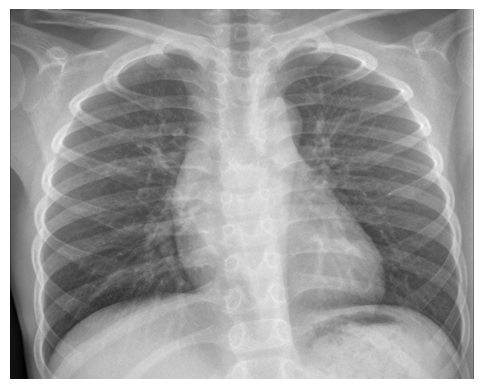

Raw Prediction: [1]
Probabilities: [[0. 1.]]
Prediction: PNEUMONIA


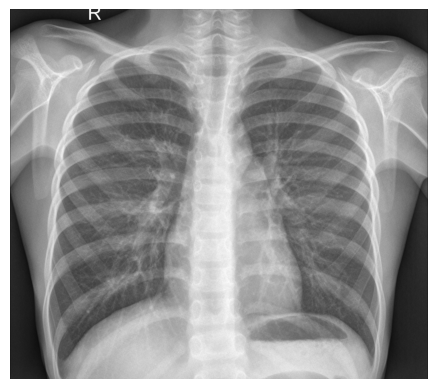

Raw Prediction: [1]
Probabilities: [[5.97457639e-11 1.00000000e+00]]
Prediction: PNEUMONIA


In [ ]:
predict_xray("../datasets/test/NORMAL/IM-0001-0001.jpeg")
predict_xray("../datasets/test/NORMAL/IM-0003-0001.jpeg")
predict_xray("../datasets/test/NORMAL/IM-0005-0001.jpeg")
predict_xray("../datasets/test/NORMAL/IM-0006-0001.jpeg")
predict_xray("../datasets/test/NORMAL/IM-0007-0001.jpeg")

In [ ]:
print(y_test[:20])

NameError: name 'y_test' is not defined

In [ ]:
import joblib

joblib.dump(model, "pneumonia_model.pkl")

print("Model Saved Successfully!")

NameError: name 'model' is not defined

In [ ]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', '_i3', '_i4', '_i5', '_i6', 'joblib', '_i7'])


In [ ]:
import os
import numpy as np
from PIL import Image

X = []
y = []

# Load NORMAL training images
normal_folder = "../datasets/train/NORMAL"
for filename in os.listdir(normal_folder):
    image_path = os.path.join(normal_folder, filename)
    try:
        img = Image.open(image_path).convert("L").resize((64, 64))
        X.append(np.array(img).flatten())
        y.append(0)
    except:
        pass

# Load PNEUMONIA training images
pneumonia_folder = "../datasets/train/PNEUMONIA"
for filename in os.listdir(pneumonia_folder):
    image_path = os.path.join(pneumonia_folder, filename)
    try:
        img = Image.open(image_path).convert("L").resize((64, 64))
        X.append(np.array(img).flatten())
        y.append(1)
    except:
        pass

print("Finished loading raw images.")

In [ ]:
X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

print("Model Training Complete!")

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/pneumonia_model.pkl")
print("Model successfully saved to ../models/pneumonia_model.pkl")

In [ ]:
print("model" in globals())

False


In [ ]:
print(os.listdir("../models"))

[]


In [85]:
print("model" in globals())

False


In [87]:
print(os.listdir("../models"))

[]


In [88]:
print(type(X))
print(type(y))
print(len(X))
print(len(y))

<class 'list'>
<class 'list'>
5216
5216


In [89]:
import numpy as np

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5216,) + inhomogeneous part.

In [91]:
for i, img in enumerate(X):
    if len(img) == 12288:
        print("RGB image found at index:", i)
        break

RGB image found at index: 1359


In [92]:
X = []
y = []

In [93]:
img = Image.open(image_path)

# Force grayscale
img = img.convert("L")

img = img.resize((64,64))

img_array = np.array(img)

flat_img = img_array.flatten()

In [94]:
img = img.convert("L")

In [95]:
lengths = set(len(img) for img in X)
print(lengths)

set()


In [96]:
X = np.array(X)
y = np.array(y)

In [98]:
count = 0

for i, img in enumerate(X):
    if len(img) == 12288:
        print(i)

        count += 1

        if count == 10:
            break

In [99]:
X = []
y = []

In [100]:
X_new = []
y_new = []

In [101]:
import os
import numpy as np
from PIL import Image

normal_folder = "../datasets/train/NORMAL"

for filename in os.listdir(normal_folder):
    try:
        image_path = os.path.join(normal_folder, filename)

        img = Image.open(image_path)
        img = img.convert("L")
        img = img.resize((64, 64))

        img_array = np.array(img)
        flat_img = img_array.flatten()

        X_new.append(flat_img)
        y_new.append(0)

    except Exception as e:
        print("Error:", filename)

In [102]:
pneumonia_folder = "../datasets/train/PNEUMONIA"

for filename in os.listdir(pneumonia_folder):
    try:
        image_path = os.path.join(pneumonia_folder, filename)

        img = Image.open(image_path)
        img = img.convert("L")
        img = img.resize((64, 64))

        img_array = np.array(img)
        flat_img = img_array.flatten()

        X_new.append(flat_img)
        y_new.append(1)

    except Exception as e:
        print("Error:", filename)

In [103]:
lengths = set(len(img) for img in X_new)
print(lengths)

{4096}


In [104]:
X_new = np.array(X_new)
y_new = np.array(y_new)

print(X_new.shape)
print(y_new.shape)

(5216, 4096)
(5216,)


In [105]:
lengths = set(len(img) for img in X_new)
print(lengths)

{4096}


In [106]:
import numpy as np

X_new = np.array(X_new)
y_new = np.array(y_new)

print(X_new.shape)
print(y_new.shape)

(5216, 4096)
(5216,)


In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4172, 4096)
(1044, 4096)


In [108]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Training Complete!")

Training Complete!


In [109]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9549808429118773


In [110]:
import joblib

joblib.dump(model, "pneumonia_model.pkl")

print("Model Saved!")

Model Saved!


In [111]:
import os

print(os.path.exists("pneumonia_model.pkl"))

True


In [114]:
print("model" in globals())

True


In [115]:
import os
print(os.path.exists("images/patient_xray.jpeg"))

False


In [117]:
import os

print(os.path.exists("../images/patient_xray.jpeg"))

True


In [121]:
from PIL import Image
import numpy as np

def predict_xray(image_path):

    img = Image.open(image_path)

    img = img.convert("L")
    img = img.resize((64, 64))

    img_array = np.array(img)

    flat_img = img_array.flatten().reshape(1, -1)

    prediction = model.predict(flat_img)

    if prediction[0] == 0:
        print("Prediction: NORMAL")
    else:
        print("Prediction: PNEUMONIA")

In [145]:
predict_xray("../datasets/test/NORMAL/IM-0001-0001.jpeg")

Probabilities: [[2.22044605e-16 1.00000000e+00]]
Prediction: PNEUMONIA


In [146]:
prediction = model.predict(X_test[0].reshape(1, -1))

print("Actual:", y_test[0])
print("Predicted:", prediction[0])

Actual: 1
Predicted: 1


In [141]:
def predict_xray(image_path):

    img = Image.open(image_path)

    img = img.convert("L")
    img = img.resize((64,64))

    img_array = np.array(img)

    flat_img = img_array.flatten().reshape(1,-1)

    prediction = model.predict(flat_img)

    probability = model.predict_proba(flat_img)

    print("Probabilities:", probability)

    if prediction[0] == 0:
        print("Prediction: NORMAL")
    else:
        print("Prediction: PNEUMONIA")

In [142]:
predict_xray("../images/normal.jpg")

Probabilities: [[1.39217526e-11 1.00000000e+00]]
Prediction: PNEUMONIA


In [138]:
import os

print(os.listdir("../images"))

['normal.jpg', 'pneumonia.jpeg']


In [128]:
predict_xray("../images/pneumonia.jpeg")

Prediction: PNEUMONIA


In [147]:
correct = 0

for i in range(20):
    pred = model.predict(X_test[i].reshape(1, -1))[0]

    print(
        f"Image {i}: Actual={y_test[i]}, Predicted={pred}"
    )

Image 0: Actual=1, Predicted=1
Image 1: Actual=0, Predicted=0
Image 2: Actual=1, Predicted=1
Image 3: Actual=1, Predicted=1
Image 4: Actual=1, Predicted=1
Image 5: Actual=1, Predicted=1
Image 6: Actual=0, Predicted=0
Image 7: Actual=0, Predicted=0
Image 8: Actual=0, Predicted=0
Image 9: Actual=0, Predicted=0
Image 10: Actual=1, Predicted=1
Image 11: Actual=0, Predicted=0
Image 12: Actual=1, Predicted=1
Image 13: Actual=1, Predicted=1
Image 14: Actual=1, Predicted=1
Image 15: Actual=1, Predicted=1
Image 16: Actual=0, Predicted=0
Image 17: Actual=1, Predicted=1
Image 18: Actual=0, Predicted=0
Image 19: Actual=1, Predicted=1


In [148]:
print(confusion_matrix(y_test, y_pred))

NameError: name 'confusion_matrix' is not defined

In [149]:
print("Actual:", y_test[0])
print("Predicted:", model.predict(X_test[0].reshape(1,-1))[0])

Actual: 1
Predicted: 1


In [150]:
from sklearn.metrics import confusion_matrix



In [151]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[260  27]
 [ 20 737]]


In [152]:
print("Actual:", y_test[0])
print("Predicted:", model.predict(X_test[0].reshape(1,-1))[0])

Actual: 1
Predicted: 1


In [154]:
test_img = X_test[0].reshape(1, -1)

print("Actual:", y_test[0])
print("Prediction:", model.predict(test_img)[0])
print("Probabilities:", model.predict_proba(test_img))

Actual: 1
Prediction: 1
Probabilities: [[8.8817842e-16 1.0000000e+00]]


In [155]:
from PIL import Image
import numpy as np

img = Image.open("../datasets/test/NORMAL/IM-0001-0001.jpeg")
img = img.convert("L")
img = img.resize((64,64))

img_array = np.array(img)

print("Shape:", img_array.shape)
print("Min:", img_array.min())
print("Max:", img_array.max())

Shape: (64, 64)
Min: 14
Max: 239


In [156]:
print(X_train.min(), X_train.max())

0 255


In [157]:
img = Image.open("../datasets/test/NORMAL/IM-0001-0001.jpeg")
img = img.convert("L")
img = img.resize((64,64))

img_array = np.array(img)

print(img_array.min(), img_array.max())

14 239


In [158]:
from PIL import Image
import numpy as np

img = Image.open("../datasets/test/NORMAL/IM-0001-0001.jpeg")
img = img.convert("L")
img = img.resize((64,64))

loaded_img = np.array(img).flatten()

print("Loaded shape:", loaded_img.shape)

print("First 20 pixels:")
print(loaded_img[:20])

Loaded shape: (4096,)
First 20 pixels:
[31 31 29 28 27 28 27 28 27 27 27 22 95 92 81 17 19 30 58 74]


In [159]:
print(X_test[0][:20])

[  2   3   3   4   3   2  17  51  75  87 104 121 151 166 169 182 181 169
 171 200]


In [160]:
correct = 0

for i in range(50):
    pred = model.predict(X_test[i].reshape(1,-1))[0]

    if pred == y_test[i]:
        correct += 1

print("Correct:", correct)

Correct: 49


In [162]:
from PIL import Image
import numpy as np

img = Image.open("../datasets/test/NORMAL/IM-0001-0001.jpeg")
img = img.convert("L")
img = img.resize((64,64))

test_vector = np.array(img).flatten()

prediction = model.predict(test_vector.reshape(1,-1))

print(prediction)

[1]


In [163]:
normal_files = [
    "IM-0001-0001.jpeg",
    "IM-0003-0001.jpeg",
    "IM-0005-0001.jpeg",
    "IM-0006-0001.jpeg",
    "IM-0007-0001.jpeg"
]

for file in normal_files:

    img = Image.open(f"../datasets/test/NORMAL/{file}")
    img = img.convert("L")
    img = img.resize((64,64))

    test_vector = np.array(img).flatten()

    pred = model.predict(test_vector.reshape(1,-1))[0]

    print(file, "->", pred)
    

IM-0001-0001.jpeg -> 1
IM-0003-0001.jpeg -> 1
IM-0005-0001.jpeg -> 1
IM-0006-0001.jpeg -> 1
IM-0007-0001.jpeg -> 1


In [164]:
print(confusion_matrix(y_test, y_pred))

[[260  27]
 [ 20 737]]


In [165]:
print("Normal in test set:", np.sum(y_test == 0))
print("Pneumonia in test set:", np.sum(y_test == 1))

Normal in test set: 287
Pneumonia in test set: 757


In [168]:
from sklearn.metrics import confusion_matrix

predictions = model.predict(X_test)

print(confusion_matrix(y_test, predictions))

print("Predicted Normal:", np.sum(predictions == 0))
print("Predicted Pneumonia:", np.sum(predictions == 1))

[[260  27]
 [ 20 737]]
Predicted Normal: 280
Predicted Pneumonia: 764


In [169]:
import random
import os
from PIL import Image
import numpy as np

normal_folder = "../datasets/test/NORMAL"

files = os.listdir(normal_folder)

sample_files = random.sample(files, 50)

correct = 0

for file in sample_files:

    img = Image.open(os.path.join(normal_folder, file))
    img = img.convert("L")
    img = img.resize((64,64))

    x = np.array(img).flatten().reshape(1,-1)

    pred = model.predict(x)[0]

    if pred == 0:
        correct += 1

print("Correct:", correct)
print("Accuracy:", correct/50)

Correct: 21
Accuracy: 0.42


In [170]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

print(accuracy_score(y_test, predictions))

0.9549808429118773


In [171]:
idx = 0
print(y_test[idx])
print(model.predict(X_test[idx].reshape(1,-1))[0])

1
1


In [172]:
for i in range(20):
    pred = model.predict(X_test[i].reshape(1,-1))[0]

    print(
        f"Index={i}, Actual={y_test[i]}, Predicted={pred}"
    )

Index=0, Actual=1, Predicted=1
Index=1, Actual=0, Predicted=0
Index=2, Actual=1, Predicted=1
Index=3, Actual=1, Predicted=1
Index=4, Actual=1, Predicted=1
Index=5, Actual=1, Predicted=1
Index=6, Actual=0, Predicted=0
Index=7, Actual=0, Predicted=0
Index=8, Actual=0, Predicted=0
Index=9, Actual=0, Predicted=0
Index=10, Actual=1, Predicted=1
Index=11, Actual=0, Predicted=0
Index=12, Actual=1, Predicted=1
Index=13, Actual=1, Predicted=1
Index=14, Actual=1, Predicted=1
Index=15, Actual=1, Predicted=1
Index=16, Actual=0, Predicted=0
Index=17, Actual=1, Predicted=1
Index=18, Actual=0, Predicted=0
Index=19, Actual=1, Predicted=1


In [5]:
predict_xray("../datasets/test/NORMAL/IM-0001-0001.jpeg")

NameError: name 'predict_xray' is not defined

In [6]:
predict_xray("../datasets/test/NORMAL/IM-0001-0001.jpeg")

NameError: name 'predict_xray' is not defined

In [8]:
predict_xray("../images/pneumonia.jpeg")

NameError: name 'predict_xray' is not defined

In [167]:
import os
from PIL import Image
import numpy as np

normal_folder = "../datasets/test/NORMAL"

correct = 0
total = 0

for file in os.listdir(normal_folder)[:50]:

    img = Image.open(os.path.join(normal_folder, file))
    img = img.convert("L")
    img = img.resize((64,64))

    x = np.array(img).flatten().reshape(1,-1)

    pred = model.predict(x)[0]

    if pred == 0:
        correct += 1

    total += 1

print("Correct Normal Predictions:", correct)
print("Total Tested:", total)

Correct Normal Predictions: 12
Total Tested: 50


In [174]:
idx = 1

print("Actual:", y_test[idx])
print("Predicted:", model.predict(X_test[idx].reshape(1,-1))[0])

print("First 20 values:")
print(X_test[idx][:20])

Actual: 0
Predicted: 0
First 20 values:
[ 10  27  50  67  74  73  76 110 117 111 114 121  97  97 102  97  91  74
  60  33]


In [12]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

..\notebooks\pneumonia_model.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py27_np17.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py33_np18.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py34_np19.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py35_np19.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.11.0_pickle_py36_np111.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np17.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py33_np18.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py34_np19.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py35_np19.pkl
..\venv\Lib\site-packages\numpy\_core\tests\data\astype_copy.pkl


In [13]:
import joblib

model = joblib.load("../notebooks/pneumonia_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [14]:
from PIL import Image
import numpy as np

def predict_xray(image_path):

    img = Image.open(image_path)

    img = img.convert("L")
    img = img.resize((64,64))

    img_array = np.array(img)

    flat_img = img_array.flatten().reshape(1,-1)

    prediction = model.predict(flat_img)

    probability = model.predict_proba(flat_img)

    print("Probabilities:", probability)

    if prediction[0] == 0:
        print("Prediction: NORMAL")
    else:
        print("Prediction: PNEUMONIA")

In [18]:
img = Image.open("../images/normal.jpg")
img = img.convert("L")
img = img.resize((64,64))

manual = np.array(img).flatten()

print(manual.shape)
print(manual.min())
print(manual.max())
print(manual[:20])

(4096,)
0
248
[  6  11  16  25  42  57  81  97 104 110 116 117 112 111 102  84  73  78
  88  83]


In [23]:
X_new
y_new

NameError: name 'X_new' is not defined

In [29]:
X_new = []
y_new = []

In [33]:
predict_xray("../datasets/test/NORMAL/IM-0007-0001.jpeg")

Probabilities: [[6.24735819e-11 1.00000000e+00]]
Prediction: PNEUMONIA


In [28]:
print("X_new" in globals())
print("y_new" in globals())

False
False


In [27]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_i10', 'os', '_i11', '_i12', 'root', 'dirs', 'files', 'file', '_i13', 'joblib', 'model', '_i14', 'Image', 'np', 'predict_xray', '_i15', '_i16', '_i17', '_i18', 'img', 'manual', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', 'train_test_split', '_i26', '_i27'])


In [34]:
predict_xray("../datasets/test/PNEUMONIA/person100_bacteria_475.jpeg")

Probabilities: [[1.48134314e-04 9.99851866e-01]]
Prediction: PNEUMONIA
